In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from scipy.stats import chi2
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os

In [9]:
os.getcwd()

'/Users/tergemina/Library/CloudStorage/Dropbox/Ionome_GWAS/1001/github/Supplementary/FigS6/FigS6a'

In [10]:
os.chdir('/Users/tergemina/Library/CloudStorage/Dropbox/Ionome_GWAS/1001/github/Supplementary/FigS5/FigS5a/')

In [11]:
araport=pd.read_table('Araport11_GFF3_genes_transposons.201606.gff.gz',skiprows=1,header=None)
araport.head()

,0,1,2,3,4,5,6,7,8
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...
1,Chr1,Araport11,mRNA,3631.0,5899.0,.,+,.,ID=AT1G01010.1;Parent=AT1G01010;Name=AT1G01010...
2,Chr1,Araport11,five_prime_UTR,3631.0,3759.0,.,+,.,ID=AT1G01010:five_prime_UTR:1;Parent=AT1G01010...
3,Chr1,Araport11,exon,3631.0,3913.0,.,+,.,ID=AT1G01010:exon:1;Parent=AT1G01010.1;Name=NA...
4,Chr1,Araport11,CDS,3760.0,3913.0,.,+,0,ID=AT1G01010:CDS:1;Parent=AT1G01010.1;Name=NAC...


In [12]:
araport_gene=araport.loc[araport[2]=='gene']
araport_gene.head()

,0,1,2,3,4,5,6,7,8
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...
19,Chr1,Araport11,gene,6788.0,9130.0,.,-,.,ID=AT1G01020;Name=AT1G01020;Note=ARV1 family p...
105,Chr1,Araport11,gene,11101.0,11372.0,.,+,.,ID=AT1G03987;locus_type=long_noncoding_rna;Nam...
109,Chr1,Araport11,gene,11649.0,13714.0,.,-,.,ID=AT1G01030;Name=AT1G01030;Note=AP2/B3-like t...
140,Chr1,Araport11,gene,23121.0,31227.0,.,+,.,ID=AT1G01040;Name=AT1G01040;Note=dicer-like 1;...


In [13]:
araport_gene['gene']=araport_gene[8].astype(str).str[3:12]
araport_gene.head()

<ipython-input-13-202a01519162>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  araport_gene['gene']=araport_gene[8].astype(str).str[3:12]


,0,1,2,3,4,5,6,7,8,gene
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...,AT1G01010
19,Chr1,Araport11,gene,6788.0,9130.0,.,-,.,ID=AT1G01020;Name=AT1G01020;Note=ARV1 family p...,AT1G01020
105,Chr1,Araport11,gene,11101.0,11372.0,.,+,.,ID=AT1G03987;locus_type=long_noncoding_rna;Nam...,AT1G03987
109,Chr1,Araport11,gene,11649.0,13714.0,.,-,.,ID=AT1G01030;Name=AT1G01030;Note=AP2/B3-like t...,AT1G01030
140,Chr1,Araport11,gene,23121.0,31227.0,.,+,.,ID=AT1G01040;Name=AT1G01040;Note=dicer-like 1;...,AT1G01040


In [23]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)
classic=parse('690_Mg_blues.assoc.txt.gz')
covariate=parse('690_Mg_blues_Chr5_282011.assoc.txt.gz')

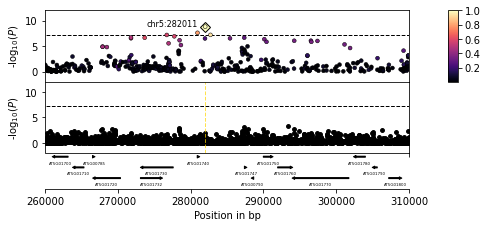

In [24]:
start = 260000
end = 310000

def zoom(df):
    return(df.loc[(df['chr'] == 5) &
                (df['ps'] > start) &
                (df['ps'] < end)])

zoom_classic=zoom(classic)
zoom_covariate=zoom(covariate)

Chr5_282011_ld=pd.read_table('Chr5_282011.ld', sep = '\s+')
Chr5_282011_ld.head()
#Combine LD info and zoom
zoom=pd.merge(zoom_classic,Chr5_282011_ld,left_on='ps',right_on='BP_B')
# test.head()

# Import araport info
araport_zoom=araport_gene.loc[(araport_gene[0] == 'Chr5') & (araport_gene[3] > start) & (araport_gene[3] < end)]

#Import color information
colors = plt.cm.magma(np.linspace(0,1,5))

def major_formatter(x, pos):
    y = x /100000
    return "%.1f" % y

from matplotlib.gridspec import GridSpec

cm = 1/2.54
fig = plt.figure(figsize=(20*cm,10*cm))
# fig = plt.figure(figsize=(10,10))
gs = GridSpec(6, 6, figure=fig, hspace=0)
ax1 = fig.add_subplot(gs[:2,:5])
ax1=sns.scatterplot(x='ps',
                y='P',
                data=zoom,
                palette='magma',
                hue='R2',
                marker='o',
                s=15,
                linewidth=0.5,
                edgecolor='k',
                legend=False,
                zorder=2)
y_SNP = zoom.loc[zoom['ps'] == 282011,'P'].values
ax1.plot(282011,y_SNP,'D',markersize=7,color=colors[4],linewidth=0.5,mec='k',zorder=1)
ax1.hlines(y=-np.log10(0.05/len(classic)),
           xmin=min(classic['position']),
           xmax=max(classic['position']),
           color='0',
           linestyle='--',
           linewidth=1,
           zorder=1)
ax1.set_xlim(start,end)
ax1.set_ylim(-2,12)
ax1.set_xlabel('')
ax1.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax1.set_xticklabels([])
ax1.annotate('chr5:282011',xy=(282011-8000,y_SNP),xytext=(282011-8000,y_SNP),fontsize=8)
ax1.axes.get_xaxis().set_visible(False)
# ax1.spines["bottom"].set_visible(False) 



ax3 = fig.add_subplot(gs[2:4,:5])
ax3=sns.scatterplot(x='ps',
                y='P',
                data=covariate,
                color='k',
                s=15,
                linewidth=1,
                edgecolor='k',
                legend=False,
                zorder=2)
ax3.hlines(y=-np.log10(0.05/len(classic)),
           xmin=min(classic['position']),
           xmax=max(classic['position']),
           color='0',
           linestyle='--',
           linewidth=1,
           zorder=1)
ax3.set_xlim(start,end)
ax3.set_ylim(-2,12)
ax3.set_xlabel('')
ax3.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax3.set_xticklabels([])
ax3.yaxis.set_major_locator(ticker.MultipleLocator(5))
# ax3.annotate('chr5:282011',xy=(261000,9),xytext=(261000,9),fontsize=8)
ax3.axvline(x=282011,linewidth=1,linestyle='--',color='gold',alpha=0.7)
# ax3.annotate('chr5:282011',xy=(261000,15),xytext=(261000,15),fontsize=8)



ax2 = fig.add_subplot(gs[4,:5])
ax2.set_xlim(ax1.get_xlim())
# ax2.axis("off")
def arrow(var,x,y):
    if var[6] == '+':
        ax2.annotate('',(var[4], x),(var[3], x),arrowprops=dict(arrowstyle='simple,head_length=0.25,head_width=.25,tail_width=.10',color='0'))
        ax2.annotate(var['gene'],(var[3]+((var[4]-var[3])/2), y),(var[3]+((var[4]-var[3])/2), y),ha='center',fontsize=4)
    if var[6] == '-': 
        ax2.annotate('',(var[3], x),(var[4], x),arrowprops=dict(arrowstyle='simple,head_length=0.25,head_width=.25,tail_width=.10',color='0'))
        ax2.annotate(var['gene'],(var[3]+((var[4]-var[3])/2), y),(var[3]+((var[4]-var[3])/2), y),ha='center',fontsize=4)
        
        
n=0
for index, row in araport_zoom.iterrows():
    if n == 0:
        arrow(row,0.9,0.7)
        n+=1
    elif n == 1:
        arrow(row,0.6,0.4)
        n+=1
    elif n == 2:
        arrow(row,0.3,0.1)
        n=0
ax2.set_yticklabels([])
ax2.axes.get_yaxis().set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
# ax2.spines["top"].set_visible(False)

ax2.set_yticklabels([])
ax2.set_xlabel('Position in bp',fontsize=10)

# Add legend
norm = plt.Normalize(zoom['R2'].min(), zoom['R2'].max())
sm = plt.cm.ScalarMappable(norm=norm,cmap='magma')
sm.set_array([])
ax3 = fig.add_subplot(gs[0:2,5])
ax3.axis('off')
# ax3.get_legend().remove()
axins = inset_axes(ax3,
                    width="15%",  
                    height="100%",
                    loc='center',
                    borderpad=-5
                   )
ax3.figure.colorbar(sm,pad=0.05,shrink=0.8,cax=axins,orientation="vertical",ticks=[1, 0.8, 0.6, 0.4, 0.2])
# plt.savefig("FigS4a.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)
plt.savefig("FigS5a.pdf", format="pdf",bbox_inches="tight")

In [25]:
classic[classic['P'] > -np.log10(0.05/len(classic))].sort_values(by='P',ascending=False)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
811509,5,5:21405867,21405867,54,G,A,0.088,-301.7630,39.38823,2.328811,2.369639,6.271519e-14,7.228329e-14,7.505019e-13,13.140962,-13.140962,121576713
811307,5,5:21392702,21392702,11,C,G,0.081,260.8489,40.67973,2.580336,2.633706,2.664290e-10,2.621355e-10,8.418870e-10,9.581474,-9.581474,121563548
811304,5,5:21392089,21392089,21,A,C,0.079,258.8815,41.92797,2.481048,2.528626,1.134956e-09,1.188955e-09,3.416293e-09,8.924835,-8.924835,121562935
648935,5,5:282011,282011,39,C,T,0.183,183.6735,29.88552,2.401857,2.440341,1.346265e-09,1.501480e-09,4.515572e-09,8.823480,-8.823480,100452857
811454,5,5:21401216,21401216,61,G,A,0.056,-295.4570,49.02923,2.431869,2.476155,2.736597e-09,2.983539e-09,8.102083e-09,8.525268,-8.525268,121572062
811312,5,5:21393289,21393289,5,T,C,0.055,-277.0624,47.22815,2.429708,2.474010,6.916865e-09,7.580551e-09,1.892023e-08,8.120299,-8.120299,121564135
811321,5,5:21394066,21394066,5,C,T,0.054,-280.9186,47.91494,2.446091,2.490400,7.061572e-09,7.640688e-09,1.887744e-08,8.116868,-8.116868,121564912
811318,5,5:21393829,21393829,13,T,C,0.080,239.5910,41.88617,2.610421,2.661995,1.588727e-08,1.565652e-08,3.369683e-08,7.805305,-7.805305,121564675
811309,5,5:21392816,21392816,15,A,T,0.399,139.3375,24.64999,2.736633,2.786499,2.315718e-08,2.202013e-08,4.503720e-08,7.657180,-7.657180,121563662
648928,5,5:280952,280952,17,G,C,0.217,159.1699,28.16340,2.489594,2.529364,2.328414e-08,2.453459e-08,5.410848e-08,7.610221,-7.610221,100451798


In [21]:
significant=classic[classic['P'] > -np.log10(0.05/len(classic))]

In [14]:
significant[['chr','ps']].to_csv('810_Mg_blues_significantSNPs_20250110.txt',index=None,header=None,sep='\t')

In [18]:
for i in significant['P'].values:
    print(i)
    

8.020943421206011
8.120838264190198
7.635262570061297
8.457919859205203
8.115183346517409
10.060031160908501
8.535825184168852
7.870585978840621
8.391050147837966
7.8879123716276345
9.542065900272481
7.293460750239668
9.735773124945501
9.380227988429708
7.234728152878257
13.599416770358395
7.841827251590758
